# Masked language modeling: predict hidden tokens

CPU companion; no accelerator is required. TPU execution not validated.

- Separate the clean targets from the corrupted input
- Normalize over selected target positions
- Verify the changed-condition exercise and explain the limits of this fixture.

A text model can see a sentence but one word is hidden. What prevents it from copying the answer, and which positions should contribute to its loss? We will train a small bidirectional attention model and audit those two boundaries.

## The idea

Masked language modeling predicts selected original tokens from a corrupted input. It differs from causal next-token prediction: allowed context can come from both sides. Our repeated-token fixture makes the correct answer inspectable; this is a small objective and attention experiment, not a BERT reproduction or a language benchmark.

## Separate the clean targets from the corrupted input

Keep an immutable copy of the original token IDs. The selection mask identifies positions to predict; corruption changes the input tokens, not the targets. Here the extra token ID $3$ means hidden, while output classes are $0,1,2$. Passing clean targets into the encoder would leak the answer. Check the corrupted arrays before the first update.

## Normalize over selected target positions

Compute log-softmax over vocabulary, gather the log probability of each original target, then average only selected positions. For uniform predictions over three classes, the initial loss is $\log 3$, regardless of how many valid positions are selected. Reject an empty mask before entering the jitted step; silently dividing by zero creates an undefined objective.

$$
L=-\frac{\sum_{b,t}m_{bt}\log p_\theta(x_{bt}\mid\widetilde x_b)}{\sum_{b,t}m_{bt}}
$$

## Use both sides without using the hidden value

The encoder forms attention scores across every input position. There is no causal triangle: a later visible token is useful evidence here. This tiny model has one attention head, no positional encoding and a linear vocabulary head. Repeated token sequences deliberately avoid word-order ambiguity; a realistic encoder also needs positions, padding handling, residual blocks and a tokenizer.

## Distinguish selection from replacement policy

This lab always replaces selected tokens with the mask ID so information flow is easy to inspect. BERT-style training can mix mask replacement, random replacement and unchanged selected tokens; selection still determines the supervised positions. Keep special/padding tokens ineligible. Track a masking key and regenerate masks under a stated schedule rather than accidentally fixing one easy corruption forever.

## Test a different corruption before claiming progress

The training curve uses one selected position. The code evaluates a second position without additional updates and checks that changing target labels changes the loss. This supports the bounded repeated-token task, not language understanding. A real corpus needs document-separated splits, a frozen tokenizer, mask provenance and downstream evaluation against random initialization.

## Run the example

In [1]:
import jax
import jax.numpy as jnp
import numpy as np

def masked_ce(logits, targets, selected):
    # Caller validates a nonempty mask before a transformed training step.
    logp = jax.nn.log_softmax(logits, axis=-1)
    nll = -jnp.take_along_axis(logp, targets[..., None], axis=-1)[..., 0]
    return jnp.sum(jnp.where(selected, nll, 0.)) / jnp.sum(selected)

def validate_mask(selected, shape):
    a = np.asarray(selected)
    if a.shape != shape or a.dtype != np.bool_ or not a.any():
        raise ValueError('a nonempty Boolean mask of the target shape is required')

def corrupt_tokens(tokens, selected, mask_id):
    validate_mask(selected, tokens.shape)
    return jnp.where(selected, mask_id, tokens)

def mlm_logits(p, corrupted):
    h = p['embedding'][corrupted]
    # Bidirectional single-head attention, deliberately no causal mask.
    scores = h @ jnp.swapaxes(h, -1, -2) / jnp.sqrt(h.shape[-1])
    context = jax.nn.softmax(scores, axis=-1) @ h
    return context @ p['head']

tokens = jnp.array([[0,0,0,0],[1,1,1,1],[2,2,2,2]],jnp.int32)
selected = jnp.array([[False,True,False,False]]*3)
corrupted = corrupt_tokens(tokens,selected,3)
key = jax.random.key(7)
p = {'embedding':jax.random.normal(key,(4,6))*.2,'head':jnp.zeros((6,3))}
loss = lambda p: masked_ce(mlm_logits(p,corrupted),tokens,selected)
step = jax.jit(jax.value_and_grad(loss)); history=[]
for _ in range(100):
    value,g = step(p); history.append(float(value)); p=jax.tree.map(lambda a,b:a-.4*b,p,g)
assert history[-1] < history[0]*.15
np.testing.assert_allclose(history[0],np.log(3),atol=1e-6)
# Changing the clean target after constructing corrupted input cannot change the forward pass.
changed_targets=tokens.at[:,1].set((tokens[:,1]+1)%3)
assert not np.isclose(float(masked_ce(mlm_logits(p,corrupted),changed_targets,selected)),history[-1])
held_mask=jnp.array([[False,False,True,False]]*3)
held_loss=float(masked_ce(mlm_logits(p,corrupt_tokens(tokens,held_mask,3)),tokens,held_mask))
assert held_loss < .2
print('MLM initial/final/changed-mask:',history[0],history[-1],held_loss)


MLM initial/final/changed-mask: 1.0986123085021973 0.010633035562932491 0.010457751341164112


Expected: Loss starts near 1.099 and ends below 0.02; an unseen mask position remains below 0.2.

## Masked language modeling: predict hidden tokens — recorded experiment

Predict: Predict what should change during training and what this curve cannot establish.

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [2]:
visual_data={'kind':'line','xlabel':'completed parameter updates before measurement','ylabel':'training objective','series':[{'label':'recorded CPU training loss','x':list(range(len(history))),'y':history}]}
for panel in visual_data.get('panels',[visual_data]):
    panel['x']=panel['series'][0]['x']


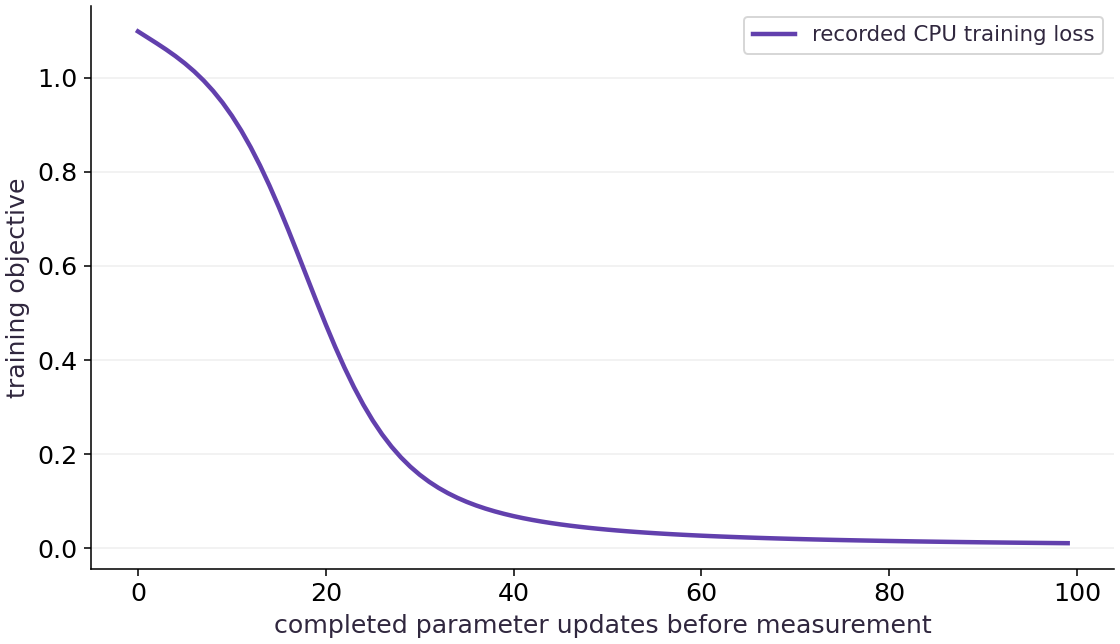

In [3]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data['unit'] in ('attention weight', 'next-token probability'):
            kw.update(vmin=0, vmax=1)
        device_ids = 'device ID' in data['unit']
        if device_ids:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            ids=np.unique(a).astype(int)
            kw.update(cmap=ListedColormap(palette[:len(ids)]), norm=BoundaryNorm(np.arange(ids.min()-0.5,ids.max()+1.5),len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if device_ids else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis is the number of updates already applied; the vertical axis is selected-token cross-entropy in nats. The first value is about $1.099=\log 3$. It falls to about $0.011$ on the fixed synthetic sequences. This is training loss, not masked-token accuracy on natural text.

### Connect it to the computation

The zero vocabulary head makes initial predictions uniform. Falling loss shows the trained attention/embedding/head system can use the remaining repeated tokens. A held mask position is checked separately; the plot does not show a held-out corpus or establish transfer quality.

## Show that unsupervised positions have no direct loss gradient

Predict: If we change logits only where the selection mask is false, does this masked objective change?

In [4]:
logits=mlm_logits(p,corrupted)
changed_logits=jnp.where(selected[...,None],logits,logits+100.)
np.testing.assert_allclose(masked_ce(changed_logits,tokens,selected),masked_ce(logits,tokens,selected),atol=1e-6)
grad_logits=jax.grad(masked_ce)(logits,tokens,selected)
np.testing.assert_array_equal(np.asarray(grad_logits)[~np.asarray(selected)],0.)
print('Unselected output logits have zero direct loss gradient.')

Unselected output logits have zero direct loss gradient.


Expected: Unselected logits do not affect the masked loss and have zero direct gradient.

Visible input tokens can still influence selected predictions through attention. Zero direct gradient at an unselected output is not a claim that visible-token embeddings never learn.

## Your exercise

Select the first position instead of the second and evaluate the trained model without updating it.

In [5]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [6]:
first_mask=jnp.array([[True,False,False,False]]*3)
first_loss=float(masked_ce(mlm_logits(p,corrupt_tokens(tokens,first_mask,3)),tokens,first_mask))
assert first_loss<.2
print('Changed position loss:',first_loss)

Changed position loss: 0.010457751341164112


## Reject a missing learning signal · Transfer

Pass an empty selection mask through the public corruption boundary and require a clear failure.

Hint: Validate outside the transformed objective before dividing by a count.

In [7]:
# Write your attempt here.

## Reference reasoning

A skipped batch requires an explicit training policy. It must not silently become a zero loss or a NaN update.

In [8]:
try:corrupt_tokens(tokens,jnp.zeros_like(tokens,dtype=bool),3)
except ValueError:print('Empty mask rejected')
else:raise AssertionError('empty mask accepted')

Empty mask rejected


## Checkpoint

Why are visible input tokens useful even when their output positions are excluded from the loss?

1. They supply context to predictions at selected positions through the encoder.
2. A lower training loss by itself proves the full application is ready.
3. Matching shapes alone establishes the required behavior.

## Diagnose

If loss is suspiciously perfect at initialization, inspect target leakage and the selection count. If loss becomes NaN, reject empty masks and inspect vocabulary indices before changing the optimizer.

## Evidence

Keep corrupted inputs, selected-target counts, the log-vocabulary baseline, independent masked-loss checks, trained parameters and changed-mask results.

## Primary references

- [BERT: masked language pretraining](https://arxiv.org/abs/1810.04805)